In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [4]:
df = pd.read_csv(r"archive (1)/placement.csv")

In [5]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [6]:
df.shape

(200, 2)

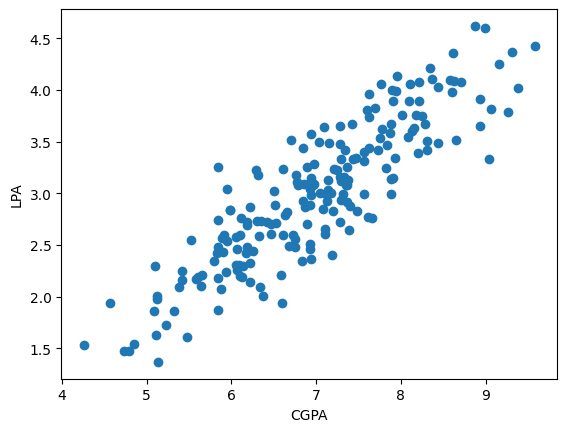

In [11]:
plt.scatter(df["cgpa"],df["package"])
plt.xlabel("CGPA")
plt.ylabel("LPA")
plt.show()

In [12]:
X = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=2)

In [15]:
from sklearn.linear_model import LinearRegression

In [16]:
lr = LinearRegression()

In [17]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
X_test

,cgpa
112,8.58
29,7.15
182,5.88
199,6.22
193,4.57
85,4.79
10,5.32
54,6.86
115,8.35
35,6.87


In [19]:
y_test

112    4.10
29     3.49
182    2.08
199    2.33
193    1.94
85     1.48
10     1.86
54     3.09
115    4.21
35     2.87
12     3.65
92     4.00
13     2.89
126    2.60
174    2.99
2      3.25
44     1.86
3      3.67
113    2.37
14     3.42
23     2.48
25     3.65
6      2.60
134    2.83
165    4.08
173    2.56
45     3.58
65     3.81
48     4.09
122    2.01
178    3.63
64     2.92
9      3.51
57     1.94
78     2.21
71     3.34
128    3.34
176    3.23
131    2.01
53     2.61
Name: package, dtype: float64

In [20]:
lr.predict(X_test.iloc[[0]])

array([3.89111601])

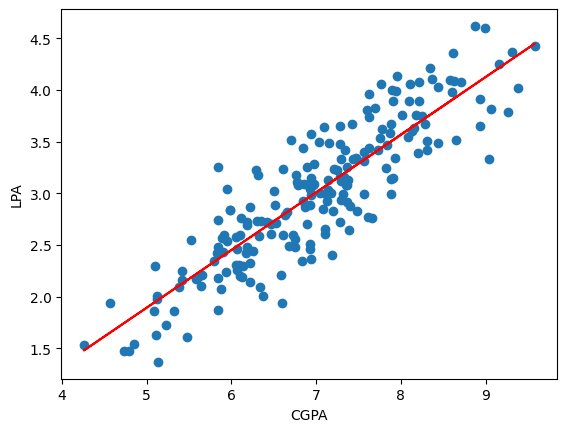

In [21]:
plt.scatter(df["cgpa"],df["package"])
plt.plot(X_train,lr.predict(X_train),color = "red")
plt.xlabel("CGPA")
plt.ylabel("LPA")
plt.show()

In [22]:
# m = slope
m = lr.coef_
m

array([0.55795197])

In [24]:
# b = intercept
b = lr.intercept_
b

np.float64(-0.8961119222429144)

In [42]:
# best fit line => y = mx + b 
y =  m * 8.58 + b
y

array([3.89111601])

In [47]:
m * 11  + b

array([5.24135979])

# Gradient Descent Method 

In [7]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [8]:
X = df["cgpa"]
y = df["package"]

In [9]:
# Initailize 
m = 0
b = 0
lr = 0.01
n = len(X)
epochs = 1000
losses = []

In [10]:
for i in range(epochs):
    y_pred = m * X + b

    # gradient 
    dm = (2/n) * np.sum((y_pred - y) * X)
    db = (2/n) * np.sum(y_pred - y)

    # update
    m = m - lr * dm
    b = b - lr * db

    # loss 
    loss = (1/n) * np.sum((y - y_pred) ** 2)
    losses.append(loss)
print("Final m: ",m)
print("Final b: ",b)

Final m:  0.4760820639419141
Final b:  -0.31707875476027947


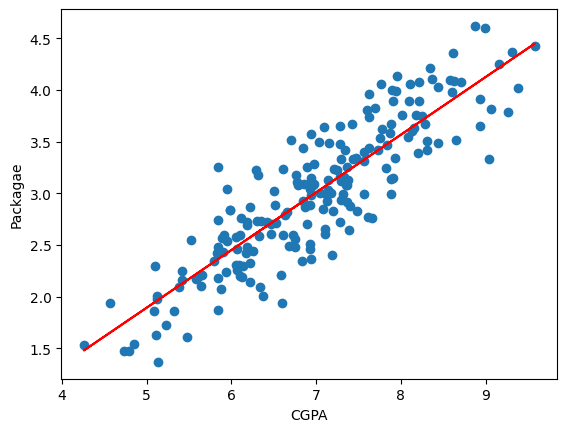

In [26]:
# plot 
plt.scatter(X,y)
plt.plot(X,m*X + b,color = "red")
plt.xlabel("CGPA")
plt.ylabel("Packagae")
plt.show()

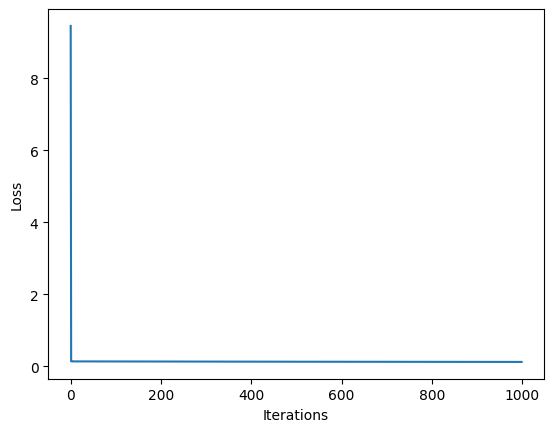

Lossess :  [np.float64(9.4522955), np.float64(0.1352245526528043), np.float64(0.13160350132895812), np.float64(0.13157997378910166), np.float64(0.13155785561580186), np.float64(0.13153575772119155), np.float64(0.13151367955109347), np.float64(0.13149162108769477), np.float64(0.13146958231340533), np.float64(0.131447563210651), np.float64(0.1314255637618731), np.float64(0.13140358394952878), np.float64(0.13138162375609086), np.float64(0.13135968316404772), np.float64(0.13133776215590334), np.float64(0.1313158607141774), np.float64(0.13129397882140523), np.float64(0.1312721164601376), np.float64(0.131250273612941), np.float64(0.1312284502623973), np.float64(0.1312066463911042), np.float64(0.13118486198167462), np.float64(0.13116309701673717), np.float64(0.13114135147893596), np.float64(0.13111962535093058), np.float64(0.1310979186153961), np.float64(0.13107623125502296), np.float64(0.13105456325251727), np.float64(0.13103291459060035), np.float64(0.131011285252009), np.float64(0.13098967

In [28]:
# Loss Curve
plt.plot(losses)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()
print("Lossess : ", losses)